# Day 24 Pre-class Assignment: "Monte Carlo" methods

### <p style="text-align: right;"> &#9989; Put your name here</p>



<img src="https://external-preview.redd.it/FCb4KAGfrjXUkRdjdBR61J-zRvURNCpbsS84bHN3AJw.jpg?auto=webp&s=bba00e8e809243ddae3bc0ad11f48cfd8dea4210" width=400px>

## **Using Random Numbers to Solve Computational Problems**

The term "Monte Carlo" refers to a [broad class of computational methods](https://en.wikipedia.org/wiki/Monte_Carlo_method) that use random numbers to solve hard computational problems; that is, we use random numbers when there is nearly no other way to solve the problem. This is a bit counterintuitive: solving scientific problems with random numbers seems like an contradiction. As we will see, Monte Carlo is a very powerful technique across the sciences and engineering. 

## **Goals for today's pre-class assignment**

* Explore how random numbers can be used to solve complicated problems (e.g. numerical integration)
* Think about the traveling salesperson problem and compute distances between artificial cities

## Assignment instructions

**This assignment is due by 11:59pm the day before class,** and should be uploaded into the appropriate "Pre-class assignments" submission folder.  Submission instructions can be found at the end of the notebook.

___
### **Monte Carlo Evaluation of an Integral**
___

We will start by writing a code to do one of the most basic tasks of calculus: finding the value of an integral. Recall that you can think of the integral of a function as the area that bounded between the function and the $x$ -axis. We will perform the integral of something for which we already know the answer so that you can check your solution analytically. The real power of Monte Carlo, or MC as it is usually referred to, in this context is in performing integrals that are vastly more complicated. In physics, for example, it is common to perform integrals in hundreds of dimensions. 

You will find the area of a circle using MC. You will assume that you know the area of a square and the function that defines a circle:

$$y = \sqrt{1 - x^2}$$

The idea is that you will pick a bunch of random numbers $x$ and $y$ in the square from $x \in [0,1]$ and $y \in [0,1]$. By seeing how many random numbers are inside the circle relative to the total, we can estimate the area of the circle (actually we're only estimating the area of $1/4$ of the circle). Another way that you can think of this as throwing darts at a dartboard. Meaning that if we throw enough darts, the area of the circle can be approximated by adding the total number of darts that hit the inside the circle. Therefore, we can get a better approximation for the area if we throw more darts. 

In order to perform this Monte Carlo integration, you need to do the following (some of these are done for you in the code cell below):
1. Set up and initialize a variable, `n_points`, that contains the number of random points you will produce. You will vary this number. As stated above, the more points, the better the approximation will be.
2. Define counter variables, `points_in` and `points_out`, and set their initial values to be $0$. You will use these variables to store information as you generate random points.
3. Set up a loop over the total number of points, using whatever type of Python loop you're most comfortable with.
4. Inside the loop choose a random $(x,y)$ pair, ensuring that the pair will be somewhere in your quandrant. 
5. Using an `if` statement, check to see if you are inside the circle or not. You should be able to use the equation $y = \sqrt{1-x^2}$ for this if statement. 
6. Update your counter variables to keep track of whether this $(x,y)$ point is inside the circle or not.
7. Once the loop is done, `print` the area of the circle using your counter variables. The area is defined as:
$$ A = \frac{N_{\mathrm{points\_in}}}{N_{\mathrm{points}}}$$
8. Also print the true area:
$$ A_{\mathrm{true}} = \frac{\pi}{4} $$

Finish the code below to produce your version of the above plot and compute the area.

(Note that the comments reference the steps listed above).

Area = 0.0
Real area = 0.7853981633974483


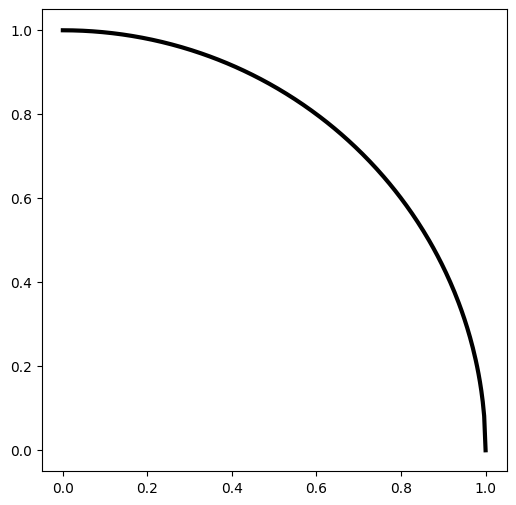

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from IPython.display import display, clear_output
import time
import random

# Complete the code below for computing the area

# My First MC Code

# Step 1: Define how many points to use
npoints = 100

# Step 2: Initialize some counter variables
points_in = 0
points_out = 0

# Set up variables for storing where the points end up
x_in = []
y_in = []
x_out = []
y_out = []

# Step 3: Loop over the total number of points
for i in range(npoints):
    
    # Step 4: Choose a random x,y location contained to the range 0 to 1 for both
    x = random.random()
    y = random.random()
    
    # Step 5 and Step 6: Check to see if y is less than sqrt(1-x^2)
    # If so, increment the "points_in" counter and store the x,y values in the x_in and y_in lists
    # If not, increment the "points_out" counter and store the x,y values in the x_out and y_out lists
    
    # DELETE THIS AND PUT YOUR CODE FOR STEPS 5 AND 6 HERE

    
# Plot the points and color them by whether they are inside or outside the circle
plt.figure(figsize=(6,6))
plt.scatter(x_in,y_in)
plt.scatter(x_out,y_out)
x = np.linspace(0,1,300)
y = np.sqrt(1-x**2)
plt.plot(x,y,lw=3,c='k')

# Step 7: Print the estimated area
print("Area =", points_in/npoints)

# Step 8: Print the real area
print("Real area =", (np.pi*1)/4.0)


___
### Animation
___

Next, animate your code above to show what is happening. Your tasks:
* Read and comment the code below. 
* Include a comment at the top that gives a quick explain of what the code does that someone else could understand. 
* **Then, copy your code from above and add this animation capability to your code.**
* Print the current area as more points are added. 

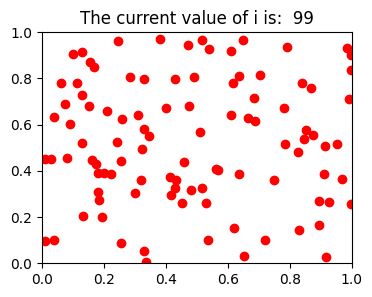

<Figure size 400x300 with 0 Axes>

In [3]:
import time 
fig = plt.figure(figsize=(4,3))

x_hold = []
y_hold = []

for i in range(100):
    x = np.random.random()
    y = np.random.random()
    x_hold.append(x)
    y_hold.append(y)
    plt.plot(x_hold,y_hold,'ro')
    plt.title('The current value of i is: %3i' %i)
    plt.xlim(0,1)
    plt.ylim(0,1)
    time.sleep(0.1)  
    clear_output(wait = True)
    display(fig)            # Reset display
    fig.clear()             # clear output for animation

In [4]:
# Copy your code here and then add in the animation parts


**You may have already played around with this animation code earlier in the course, but if you haven't you should make sure you understand it now.**

____
## Optimization
___

MC is useful for performing optmization problems as well. Optimization means pretty much what it sounds like: we want to find the optimal value for something. In fact, we have already seen this in regression: when we find the best fit of a line to some data we are optimizing the values of the parameters to make the line have the smallest distance from the data points. But, optimization can take many forms beyond this simple example. 

<img src="https://www.math.uwaterloo.ca/tsp/usa50/img/olson_screen.png" width=450>

In the in-class assignment, we will explore one of the classic optimization problems: the **[Traveling Salesperson Problem](https://en.wikipedia.org/wiki/Travelling_salesman_problem)**. The basic problem is this: you have $N$ cities to travel between and you would like to find the shortest route, going through each city only once. This is fairly easy when $N$ is small, but becomes extremely difficult when $N$ is large - you simply cannot wait for the computer to search every possibile route. 

One way to attack problems of this kind is to recognize that it may be impossible to find the absolute best (most optimal) solution. It might be perfectly fine to simply have a really good solution sooner rather than never. This allows us to use MC methods: we can randomly choose different routes and see which ones are shortest; if we are clever, we can make an algorithm that attempts to get better each time it makes a new attempt. 

But, we will save all of that fun for once you get to class!

For now, let's just think about how to set up such a problem. One of the most challenging aspects of the Traveling Salesperson Problem is that there are many steps involved and you will need to break it down into pieces. For now, here are your tasks:

* **Write a function** that takes as input the number of cities, $N$.
* For now we will not use real cities, so within the function create the locations of $N$ cities using random numbers. For convenience, you can just assume that the cities fall on a map in the range $x \in [0,1]$ and $y \in [0,1]$. Every city will have a random $(x,y)$ location in that range. 
* **Return** from the function the coordinates of the $N$ cities as two arrays ($x$ values and $y$ values)
* Call the function and store those returned array in some variables. Then, Make a plot to be sure it is working.

You should get something that looks like this (with points in different locations, of course):

<img src="https://i.imgur.com/uhRoXQs.png" width=400px>

In [6]:
# Put your code here


Once that function is working, do the following:

* **Write a second function called "`calculate_distances`"** that receives the two arrays, a set of $x$ values and a set for $y$ values for your $N$ cities, and **returns a 2D array with the distances between all of the points**. This provides a lookup table for finding the distances between any two cities. The distance between two points is defined as:

$$ D = \sqrt{(x_1 - x_2)^2 + (y_1 - y_2)^2}. $$

The elements in the 2D array correspond to the distances between cities in the following way: If you consider the first row (indexed as 0) and the second column (indexed as 1), then that value at $D[0,1]$ represents the distance bewteen the first and second city (in that order). Similarly, the value at $D[5,2]$ is the distance between city 6 and city 3 (in that order). In this situation, all the distances are symmetric so as an example, $D[2,5] = D[5,2]$.

**Hint**: You should be able to create an empty 2D array and then used nested loops to fill the array with distances. A quick check to make sure that you have the correct 2D array is to make sure that the elements on the diagonal of the array are all zero. This is true as the distance between a city with itself is zero. For $N$ = 4, the distance matrix might look like this:
```
[[0.         0.31528794 0.47635924 0.30767835]
 [0.31528794 0.         0.70425937 0.23807393]
 [0.47635924 0.70425937 0.         0.78078259]
 [0.30767835 0.23807393 0.78078259 0.        ]]
 ```

In [8]:
# Put your code here


### Computing the total distance traveled

Now, let's assume you will simply go through the cities in order the first time. The following code prints the total distance of the path through the cities assuming you go from city $1$ to city $2$, city $2$ to city $3$, and so on. Along the way, it makes a plot that shows the route by putting lines betwen the points and the lines get darker as the salesperson moves through their route. This will only work if you managed to create the 2D distance array. The code also animates the plot so that you can watch it in "real time" as the salesperson moves from one city to the next.

If you created the distance matrix correctly, you should eventually end up with something that looks similar to this:

<img src="https://i.imgur.com/tnmLINv.png" width=400px>

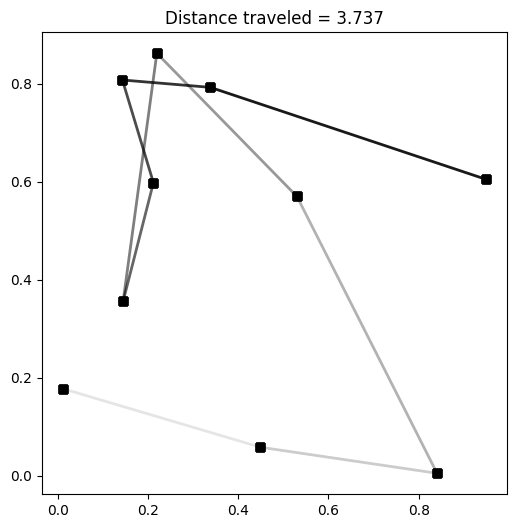

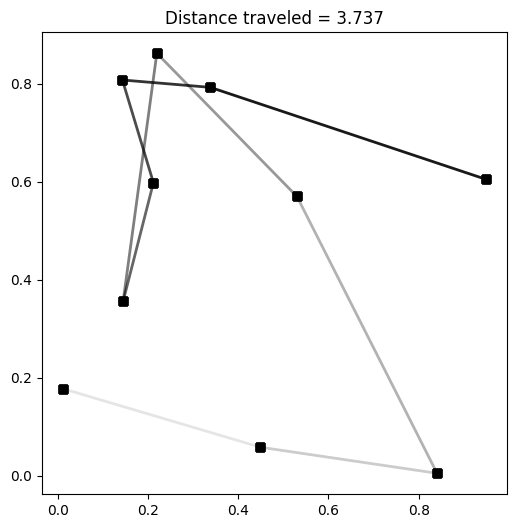

In [7]:
# Make sure you understand how this code works!

# We use the calculate_distances function you created above to compute the distance matrix
# Make sure you feed in the correct "x" and "y" arrays if you used different variables names
D = calculate_distances(x,y)

fig = plt.figure(figsize=(6,6))
total_distance = 0
for i in range(n_city-1):
    plt.scatter(x,y,marker="s",c="k");
    plt.plot([x[i],x[i+1]], [y[i],y[i+1]],
             alpha=(i+1)/(n_city),lw=2,color="k");
    total_distance += D[i,i+1]
    plt.title("Distance traveled = %0.3f" %total_distance)
    time.sleep(1.0)  
    clear_output(wait = True)
    display(fig) # Reset display

plt.savefig("the_journey.png")

___
### Assignment wrapup

Please fill out the form that appears when you run the code below.  **You must completely fill this out in order to receive credit for the assignment!**

___

In [ ]:
from IPython.display import HTML
HTML(
"""
<iframe 
	src="https://forms.office.com/r/L7tKvVciTd" 
	width="800px" 
	height="600px" 
	frameborder="0" 
	marginheight="0" 
	marginwidth="0">
	Loading...
</iframe>
"""
)

### Congratulations, you're done!

Submit this assignment by uploading it to the course Desire2Learn web page.  Go to the "Pre-class assignments" folder, find the appropriate submission link, and upload it there.

See you in class!

&#169; Copyright 2026, The Department of Computational Mathematics, Science and Engineering at Michigan State University